In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Ramanujan-Hardy-Taxi

In [3]:
# Ramanujan Number finder
def ramanujan_num(N): 
    numbers = []
    # Choose 4 distinct numbers below N^(1/3) 
    for p in range(1, int(N**(1/3)) + 1):
        for q in range(p, int(N**(1/3)) + 1):
            for r in range(p+1, int(N**(1/3)) + 1):
                for s in range(r, int(N**(1/3)) + 1):

                    # Test for Ramanujan number criteria
                    if p**3 + q**3 == r**3 + s**3 and p**3 + q**3 < N:
                        numbers.append((p, q, r, s))

    for p, q, r, s in numbers:
        print(f"{p**3 + q**3} = {p}^3 + {q}^3 = {r}^3 + {s}^3")
            
N = int(input("Ramanujan numbers below: "))
ramanujan_num(N)

Ramanujan numbers below:  100000


1729 = 1^3 + 12^3 = 9^3 + 10^3
4104 = 2^3 + 16^3 = 9^3 + 15^3
13832 = 2^3 + 24^3 = 18^3 + 20^3
39312 = 2^3 + 34^3 = 15^3 + 33^3
46683 = 3^3 + 36^3 = 27^3 + 30^3
32832 = 4^3 + 32^3 = 18^3 + 30^3
40033 = 9^3 + 34^3 = 16^3 + 33^3
20683 = 10^3 + 27^3 = 19^3 + 24^3
65728 = 12^3 + 40^3 = 31^3 + 33^3
64232 = 17^3 + 39^3 = 26^3 + 36^3


# 2. Greatest Common Denominator (GCD)

In [4]:
# Recursive GCD program
def gcd(m, n):
    if n == 0:
        return print(f'GCD({M, N}) = {m}')
    return gcd(n, m % n)

M = int(input("m = "))
N = int(input("n = "))
gcd(N, M)

m =  36
n =  60


GCD((36, 60)) = 12


# 3. Newton-Raphson Fractal

In [5]:
# Polynomial
n = 3
def f(x): 
    return x**n - 1
    
# Derivative 
def df(x):
    return n*x**(n-1)

# Newton-Raphson Function
def newton_method(x0, eps=1e-5, N=50):
    for i in range(N):
        x1 = x0 - (f(x0)/df(x0))
        if np.abs(x1 - x0) < eps:
            break
        else:
            x0 = x1
    return x1

I have chosen to assign the colors for the plot automatically using plt.imshow() because this allows us the flexibility to plot the roots for different orders of x^n=1 by simply choosing a different n. The colors chosen also maintain reasonable contrast when picked from the appropriate colormap. 

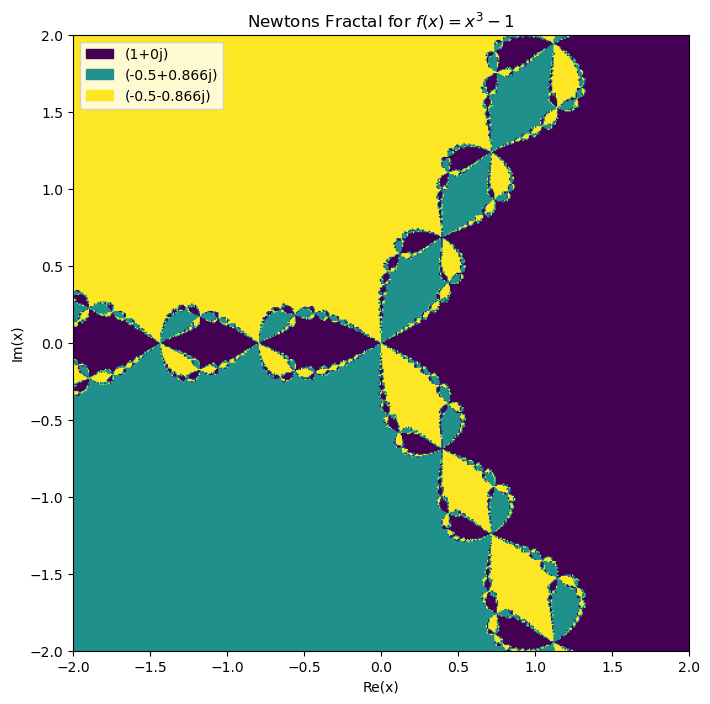

In [10]:
# Newton-Raphson Fractal
res = 500  # resolution (reduce resolution to render faster)
lim = 2    # limits
x = np.linspace(-lim, lim, res)
y = np.linspace(-lim, lim, res)
X, Y = np.meshgrid(x, y)
Z = X + Y*1j

R = [np.exp(2j * np.pi * k / n) for k in range(n)] # general formula for the roots of x^n=1

value = np.zeros(Z.shape, dtype=int)

for i in range(res):
    for j in range(res):
        root = newton_method(Z[i, j])
        err = [np.abs(root - r) for r in R]
        value[i, j] = np.argmin(err)  # choose value that the estimated root is closest to (minimum error)

plt.figure(figsize=(8, 8))
plt.imshow(value, extent=(-lim, lim, -lim, lim), cmap='viridis')
plt.title(f'Newtons Fractal for $f(x) = x^{n} - 1$')
plt.xlabel('Re(x)')
plt.ylabel('Im(x)')

# Legend (Created using ChatGPT)
colors = [plt.cm.viridis(i / (n - 1)) for i in range(n)]
patches = [mpatches.Patch(color=colors[i], label=f'{np.round(R[i], 3)}') for i in range(n)]
plt.legend(handles=patches, loc='upper left', fontsize=10, frameon=True)

plt.show()

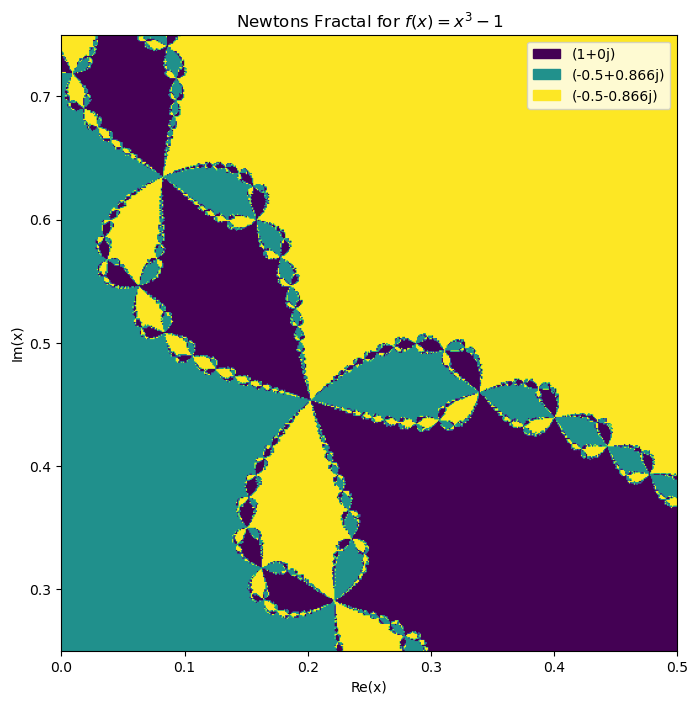

In [11]:
# Zoomed-In Plot
x = np.linspace(0, 0.3, res)
y = np.linspace(0.4, 0.7, res)
X, Y = np.meshgrid(x, y)
Z = X + Y*1j

value = np.zeros(Z.shape, dtype=int)

for i in range(res):
    for j in range(res):
        root = newton_method(Z[i, j])
        value[i, j] = np.argmin([np.abs(root - r) for r in R])

plt.figure(figsize=(8, 8))
plt.imshow(value, extent=(0, 0.5, 0.25, 0.75), cmap='viridis')
plt.title(f'Newtons Fractal for $f(x) = x^{n} - 1$')
plt.xlabel('Re(x)')
plt.ylabel('Im(x)')
plt.legend(handles=patches, loc='upper right', fontsize=10, frameon=True)
plt.show()